<div style="background-color:#5A3516; color:#F3EEE6; padding:22px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h1 style="color:#F3EEE6; margin-bottom:0;"><b>Machine Learning II — Customer Segmentation</b></h1>
<h3 style="color:#D8C0B4; margin-top:6px;">Notebook 1 — Exploratory Data Analysis and Preprocessing</h3>
<p style="color:#D8C0B4; font-size:15px; margin-top:14px;">
This notebook prepares the <code>customer_info</code> dataset for the clustering stage. The goal is to clean the data, engineer meaningful customer features, protect identifiers from distance transformations and export an unscaled dataset ready for clustering.
</p>
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:18px; border-radius:10px; border-left:8px solid #A8B7BA;">

<h2 style="color:#F3EEE6; margin-top:0;"><b>Index</b></h2>

<p style="color:#D8C0B4;">This index follows the full workflow from raw data inspection to the final export used for clustering.</p>

<ol>
  <li><a href="#section-1-imports-and-data-loading">Imports and Data Loading</a></li>
  <li><a href="#section-1-1-data-analysis">Initial Data Analysis</a></li>
  <li><a href="#section-1-2-duplicate-rows-analysis">Duplicate Rows Analysis</a></li>
  <li><a href="#section-1-3-missing-values-analysis">Missing Values Analysis</a></li>
  <li><a href="#section-1-4-numerical-and-categorical-columns">Numerical and Categorical Columns</a></li>
  <li><a href="#section-1-5-statistical-summary">Statistical Summary</a></li>
  <li><a href="#section-2-data-cleaning">Data Cleaning</a></li>
  <li><a href="#section-2-1-invalid-future-years">Invalid Future Years</a></li>
  <li><a href="#section-2-2-negative-values">Negative Values</a></li>
  <li><a href="#section-2-3-negative-percentages">Negative Percentages</a></li>
  <li><a href="#section-2-4-data-types">Data Type Fixes</a></li>
  <li><a href="#section-2-5-missing-values-treatment">Missing Values Treatment</a></li>
  <li><a href="#section-3-aggregation-feature-engineering">Aggregation Feature Engineering</a></li>
  <li><a href="#section-4-outlier-separation-and-imputation">Consensus Outlier Separation and KNN Imputation</a></li>
  <li><a href="#section-5-transformation-feature-engineering">Transformation Feature Engineering</a></li>
  <li><a href="#section-6-outlier-diagnostics">Outlier Diagnostics</a></li>
  <li><a href="#section-7-multivariate-analysis">Multivariate Analysis</a></li>
  <li><a href="#section-8-feature-selection-and-export">Feature Selection and Final Export</a></li>
</ol>

</div>


<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1. Imports and Data Loading</b></h2>
</div>


In [117]:
import warnings

import pandas as pd

warnings.filterwarnings("ignore")

import utils_eda as utils

utils.set_plot_style()
pd.set_option("display.max_columns", None)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:20px; border-radius:10px;">

We start by loading the core library used in this notebook and the project utility module. Most repeated EDA and preprocessing steps are kept in <code>utils_eda.py</code>, so the notebook remains focused on decisions, outputs and interpretation.

</div>

<a id="section-1-1-data-analysis"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1.1 Initial Data Analysis</b></h2>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:20px; border-radius:10px;">

After loading the dataset, we inspect its shape, column types, and sample records. This gives us a quick sense of what needs to be cleaned before we start creating features for clustering.

</div>


In [118]:
DATA_PATH = "../datasets/customer_info.csv"
ci = pd.read_csv(DATA_PATH)

In [119]:
ci.sort_index(inplace=True)
display(ci.head())


,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,28.0,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,43.0,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,118.0,1265.0,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,1133.0,972.0,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,718.0,1068.0,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [120]:
display(ci.tail())

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
33033,39996,Joshua Howard,male,05/16/1973 02:04 PM,0.0,0.0,2.0,1.0,475.0,13488.0,NaN,190.0,573.0,994.0,1020.0,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,NaN,38.742306,-9.163971
33034,39997,Anthony Hines,male,05/10/1955 01:19 AM,1.0,0.0,1.0,1.0,8430.0,14408.0,21.0,291.0,497.0,1417.0,1323.0,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,NaN,38.748505,-9.193445
33035,39998,Edna Hasselman,female,05/15/1945 11:09 PM,1.0,1.0,0.0,4.0,8029.0,1480.0,14.0,1600.0,494.0,117.0,307.0,NaN,1719.0,89.0,258.0,206.0,0.181917,2012.0,NaN,38.776003,-9.137943
33036,39999,George Kramer,male,05/25/1951 09:02 PM,1.0,1.0,1.0,6.0,8364.0,3114.0,11.0,596.0,303.0,661.0,NaN,113.0,410.0,NaN,225.0,385.0,0.807259,2017.0,NaN,38.736034,-9.145235
33037,40000,Sammie Wright,female,07/09/1990 10:27 AM,0.0,1.0,1.0,1.0,4774.0,2127.0,7.0,701.0,387.0,126.0,816.0,729.0,1331.0,323.0,239.0,102.0,0.252563,2017.0,NaN,38.758936,-9.145988


<div style="background-color:#7E6A43; color:#F3EEE6; padding:20px; border-radius:10px;">
We use the `.info()` method to verify the column names, not null counts, and data types. This allows us to identify columns that require type conversion (e.g., dates or numerical counts stored as floats) and gives us an initial glimpse of the data density.

In [121]:
display(ci.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  object 
 2   customer_gender                          33038 non-null  object 
 3   customer_birthdate                       32873 non-null  object 
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377

None

<a id="section-1-2-duplicate-rows-analysis"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1.2 Duplicate Rows Analysis</b></h2>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:20px; border-radius:10px;">
To ensure the reliability of our clusters, we check for duplicate records. Duplicate rows can artificially inflate the importance of certain customer profiles and lead to biased segmentation results.

In [122]:
duplicate_rows = ci[ci.duplicated()]
display(duplicate_rows.head())

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude


<div style="background-color:#7E6A43; color:#F3EEE6; padding:20px; border-radius:10px;">
While checking for exact row duplicates is standard, it is also important to perform a more granular search for "logical duplicates". 

In this step, we specifically look for records that share the same **Customer Name** and **Birthdate**. Identifying such cases is vital because:
* **Data Overlap:** The same individual might have been registered twice under different IDs.
* **Clustering Bias:** If the same customer profile appears multiple times, it will unfairly pull a cluster center toward its specific attributes, distorting the final segmentation.

In [123]:
ci[ci[['customer_name', 'customer_birthdate']].duplicated()]

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude


<a id="section-1-3-missing-values-analysis"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1.3 Missing Values Analysis</b></h2>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:20px; border-radius:10px;">
    
Missing data is a common challenge in customer datasets. We generate a missing value report to:
* Quantify the percentage of missing information per feature.
* Visualize the missing data using a barplot.
* Determine which variables require **KNN Imputation** and which ones might be too empty to be useful.

In [124]:
missing_df = utils.get_missing_percent(ci)

In [125]:
display(missing_df.sort_values("Missing_Percent", ascending=False).head(15))

,Column,Missing_Percent
22,loyalty_card_number,39.67
15,lifetime_spend_fish,3.00
9,lifetime_spend_electronics,2.00
17,lifetime_spend_videogames,2.00
14,lifetime_spend_meat,2.00
11,lifetime_spend_vegetables,2.00
10,typical_hour,2.00
18,lifetime_spend_petfood,2.00
6,number_complaints,2.00
16,lifetime_spend_hygiene,1.00


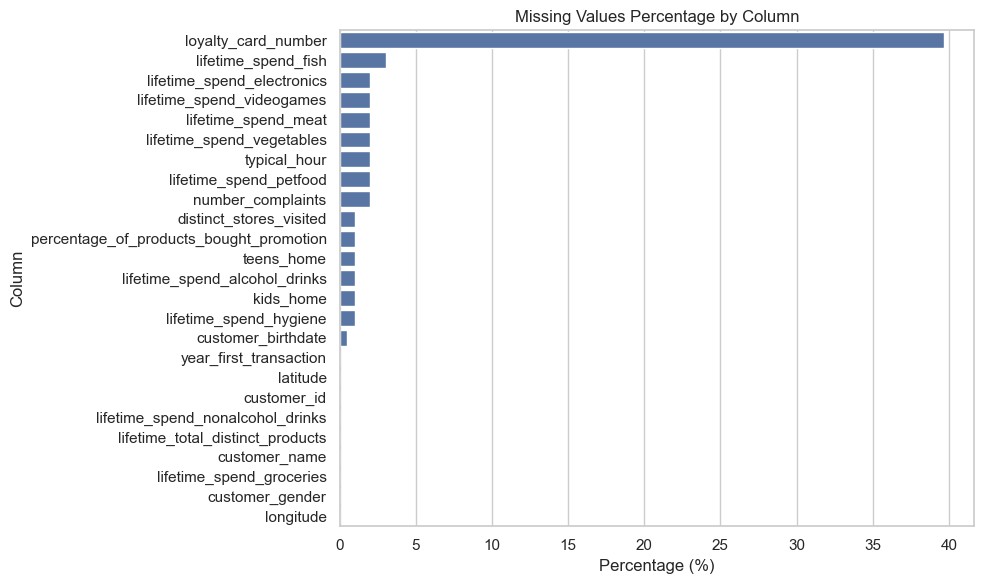

In [126]:
utils.plot_missing_percent(missing_df)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

We identify features with a missing value percentage higher than **30%**. This threshold is critical because:
* **Information Loss:** Variables with high sparsity often lack enough signal to be reliably imputed.
* **Model Integrity:** Including features with excessive missing data can introduce significant noise into the clustering process, potentially leading to distorted segments.


In [127]:
high_missing = missing_df[missing_df['Missing_Percent'] > 30]
display(high_missing)

,Column,Missing_Percent
22,loyalty_card_number,39.67


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The missing value inspection shows that the dataset is usable without dropping large parts of the customer base. The missing values are concentrated in a limited group of behavioural and spend variables, which supports using imputation later instead of removing customers prematurely.
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
We evaluate the number of unique values in the `loyalty_card_number` column to determine its nature.

In [128]:
print(f"Unique Values of column loyalty_card_number: {ci['loyalty_card_number'].nunique()}")

Unique Values of column loyalty_card_number: 1


<a id="section-1-4-numerical-and-categorical-columns"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1.4 Numerical and Categorical Columns</b></h2>
</div>


In [129]:
numerical_cols, categorical_cols = utils.get_column_groups(ci)

print(f"Numerical columns ({len(numerical_cols)}):")
display(pd.DataFrame(numerical_cols, columns=["Numerical Columns"]))

print(f"Categorical columns ({len(categorical_cols)}):")
display(pd.DataFrame(categorical_cols, columns=["Categorical Columns"]))


Numerical columns (22):


,Numerical Columns
0,customer_id
1,kids_home
2,teens_home
3,number_complaints
4,distinct_stores_visited
5,lifetime_spend_groceries
6,lifetime_spend_electronics
7,typical_hour
8,lifetime_spend_vegetables
9,lifetime_spend_nonalcohol_drinks


Categorical columns (3):


,Categorical Columns
0,customer_name
1,customer_gender
2,customer_birthdate


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px; ">

To properly prepare our preprocessing pipeline, we categorize the variables into Numerical and Categorical types. This distinction is essential as each group requires specific cleaning and transformation strategies.

Numerical Features (21 Variables)
These columns represent quantitative data, including spending amounts, household counts, and geographic coordinates.
* **Household & Behavior:** `kids_home`, `teens_home`, `number_complaints`, `distinct_stores_visited`.
* **Spending Habits:** `lifetime_spend_` (Groceries, Electronics, Vegetables, Non alcoholic, Alcohol, Meat, Fish, Hygiene, Videogames, Petfood).
* **Metrics & Time:** `lifetime_total_distinct_products`, `percentage_of_products_bought_promotion`, `typical_hour`, `year_first_transaction`.
* **Geospatial & IDs:** `latitude`, `longitude`, `loyalty_card_number`.

Categorical Features (3 Variables)
These columns contain qualitative information or timestamps that define the customer profile.
* **Demographics:** `customer_gender`.
* **Identification:** `customer_name`.
* **Temporal:** `customer_birthdate` (to be used for age calculation).

</div>

<a id="section-1-4-1-categorical-columns"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1.4.1 Findings in Categorical Columns</b></h2>
</div>


In [130]:
ci[["customer_name"]]

,customer_name
0,Bsc. Crystal Kitchens
1,Bsc. Glenda Bauman
2,Msc. Antonio Campbell
3,John Kelling
4,Arthur Dematteo
...,...
33033,Joshua Howard
33034,Anthony Hines
33035,Edna Hasselman
33036,George Kramer


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

A detailed inspection of the `customer_name` field shows that several names include academic prefixes such as **BSc.**, **MSc.**, and **PhD.**

* **Observation:** The dataset contains 33,038 unique customer names.
* **Feature Engineering Opportunity:** These prefixes can be used as a proxy for the customer's **education level**. They are converted into approximate years of education: 12 for customers without a prefix, 15 for BSc, 17 for MSc, and 22 for PhD.
* **Data Cleaning:** After extracting this information, the raw name field is no longer needed for modelling.

</div>


<a id="section-1-5-statistical-summary"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1.5 Statistical Summary</b></h2>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
    
We perform a statistical summary of the numerical features using the `.describe()` method. This allows us to observe the central tendency, dispersion, and range of our variables, providing critical insights into the data's distribution.


In [131]:
print("Statistical summary for numerical columns:")
ci[numerical_cols].describe().T

Statistical summary for numerical columns:


,count,mean,std,min,25%,50%,75%,max
customer_id,33038.0,19974.265785,11538.538632,3.000000,9985.250000,19951.500000,29964.750000,40000.000000
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

Based on the summary table, we can identify several areas that require attention during preprocessing:

* **Constant Features:** `loyalty_card_number` does not add useful behavioural information for clustering.
* **Data Entry Errors:** `percentage_of_products_bought_promotion` contains impossible values below 0, and `year_first_transaction` contains future years.
* **Spending Variance:** The spending variables show strong dispersion, suggesting heterogeneous purchasing behaviour and the presence of extreme customers.
* **Missing Data:** Several columns have incomplete values and therefore require treatment before modelling.

</div>


In [132]:
condition = (ci['percentage_of_products_bought_promotion'] < 0.0) | (ci['percentage_of_products_bought_promotion'] > 1.0)
rows_wrong = ci[condition]
display(rows_wrong.head())

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
8,12,Phd. Dorothy Pacheco,female,05/19/2000 03:02 AM,0.0,0.0,0.0,2.0,9281.0,254.0,18.0,125.0,60.0,1549.0,139.0,598.0,673.0,71.0,64.0,29.0,-0.131176,2018.0,NaN,38.748616,-9.167756
26,35,Bsc. Thomas King,male,08/08/1979 05:25 AM,NaN,1.0,0.0,2.0,37795.0,2130.0,8.0,636.0,102.0,310.0,890.0,844.0,842.0,42.0,524.0,212.0,-0.025524,2011.0,1.0,38.762036,-9.158847
28,37,Phd. Alonzo Crossan,male,09/29/2000 07:54 PM,1.0,1.0,0.0,5.0,25539.0,1089.0,7.0,907.0,1681.0,896.0,1153.0,962.0,1205.0,344.0,329.0,330.0,-0.184820,2028.0,1.0,38.729700,-9.196585
65,81,Phd. Denise Allard,female,03/18/1992 06:34 PM,2.0,0.0,2.0,1.0,6273.0,430.0,6.0,208.0,291.0,525.0,539.0,804.0,707.0,121.0,320.0,91.0,-0.217805,2020.0,1.0,38.748092,-9.155615
71,87,Phd. Milagro Amelung,female,09/03/1977 11:26 AM,1.0,1.0,1.0,3.0,28825.0,2948.0,15.0,459.0,687.0,716.0,884.0,1495.0,1314.0,161.0,916.0,337.0,-0.022180,2008.0,1.0,38.776791,-9.146792


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

We perform a targeted integrity check on the `percentage_of_products_bought_promotion` feature. Since this variable represents a ratio, any value outside the range of **[0, 1]** is considered a data entry error.

* **Condition defined:** We filter for values strictly less than 0.0 or greater than 1.0.
* **Findings:** As noted in the descriptive statistics, there are records with negative values (e.g., -1.27), which are physically impossible.
* **Objective:** Identifying these specific rows allows us to treat them as "missing data" (NaN), ensuring they are later corrected by our **KNN Imputation** strategy rather than biasing our analysis with impossible values.

</div>

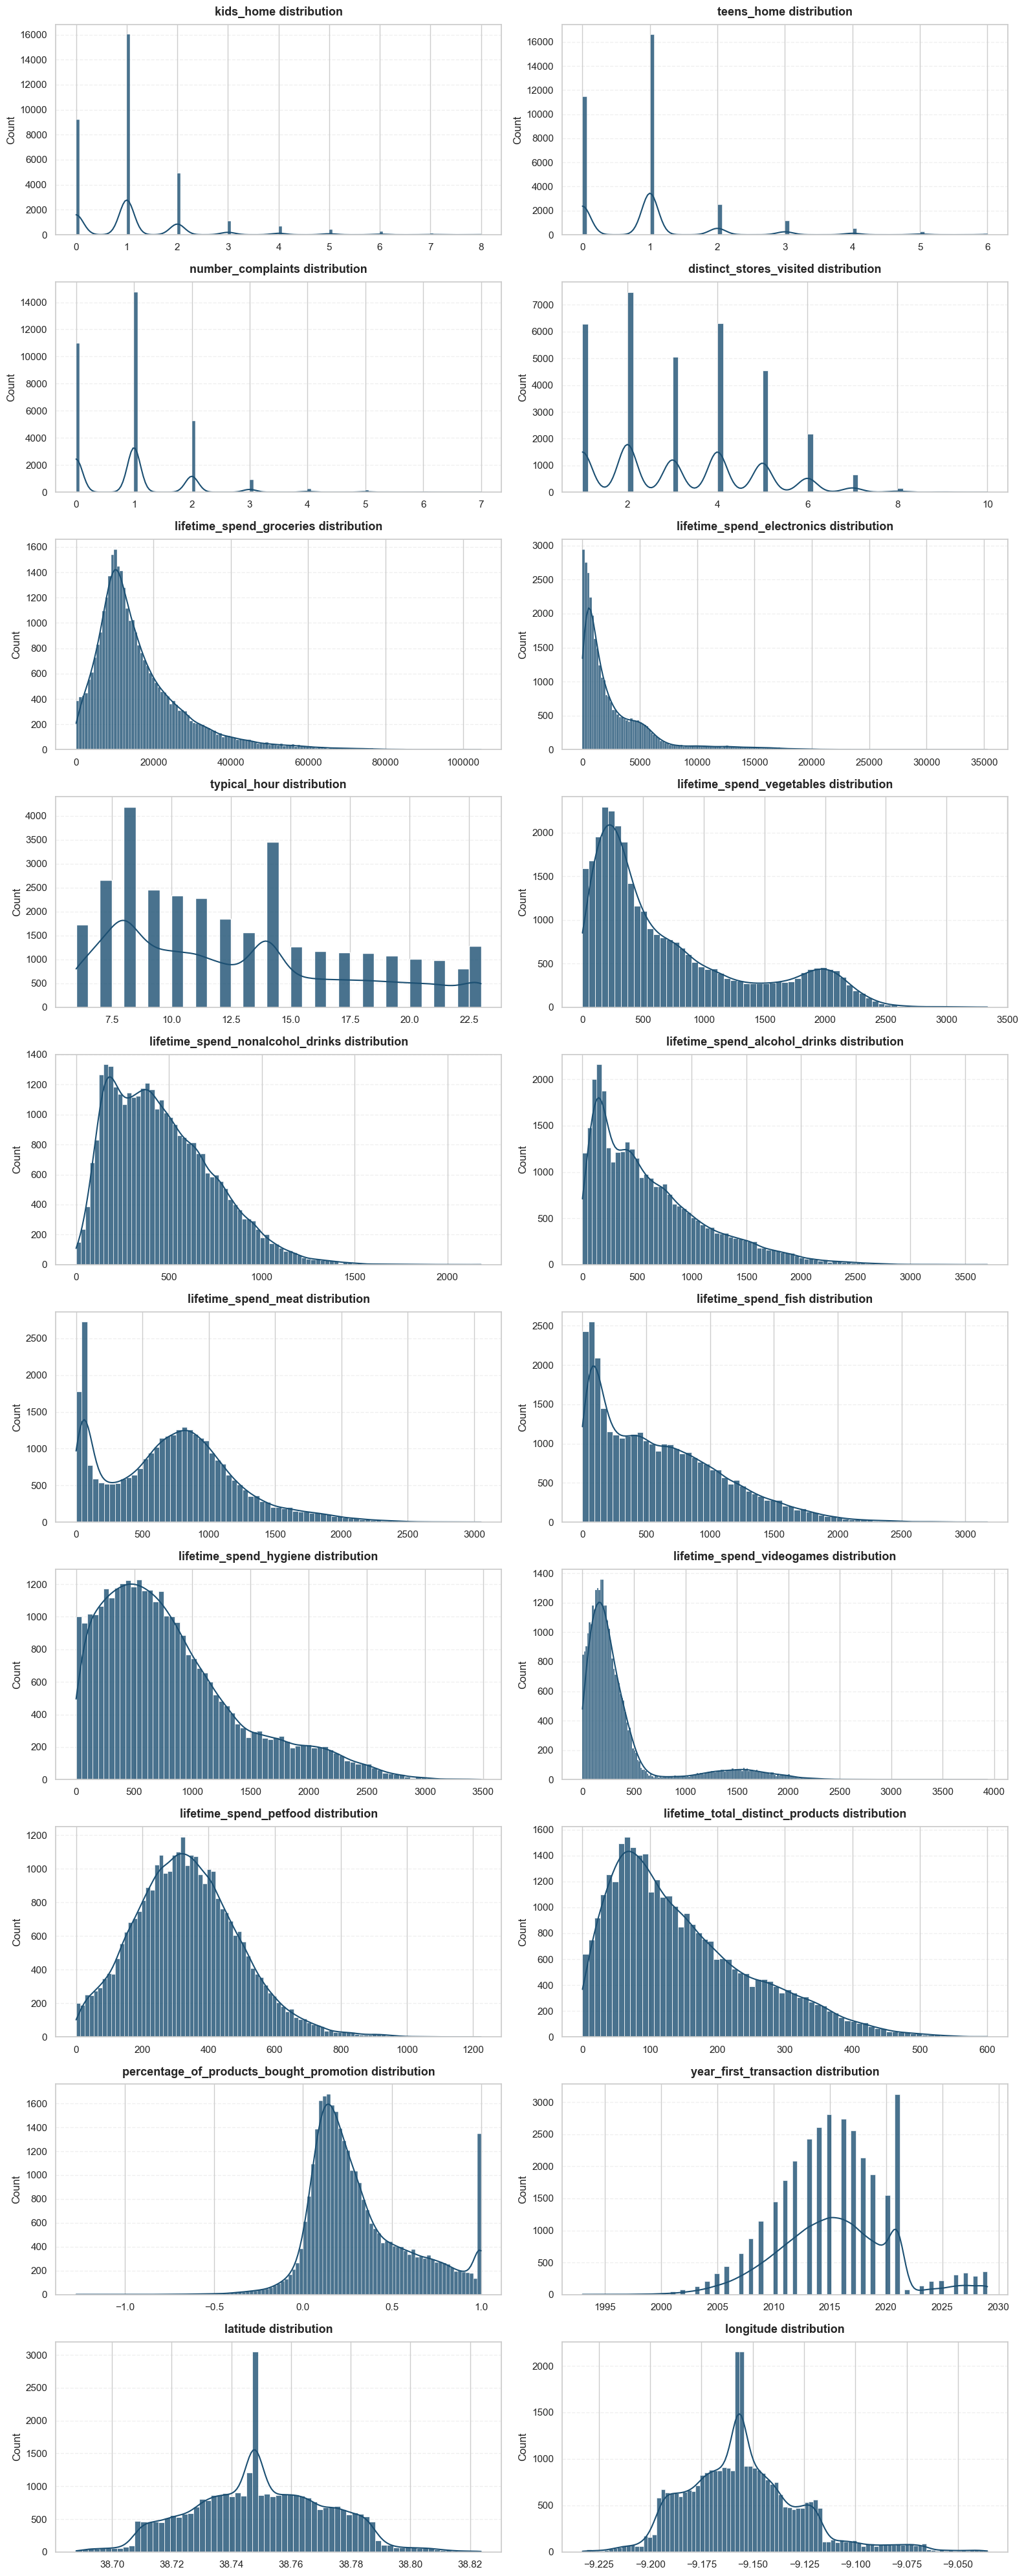

In [133]:
vars_to_plot = utils.numeric_columns_for_eda(
    ci,
    exclude_cols=["loyalty_card_number", "customer_id", "customer_loyalty_flag"],
)

utils.plot_numeric_distributions(ci, vars_to_plot)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

The histograms allow us to understand the shape of the customer base.

#### **Spending Categories**
* **Skewness:** Most spending features are skewed to the right: many customers spend relatively little, while a smaller group spends much more.
* **Outliers:** The boxplots confirm the presence of extreme customers. These cases are separated before clustering instead of being allowed to dominate the distance calculation.

#### **Temporal & Behavioral Patterns**
* **Typical Hour:** Time of day is cyclical, so we use sine/cosine transformation to preserve the proximity between late night and early morning hours.
* **Promotion Sensitivity:** The promotion percentage helps distinguish customers who buy more frequently under promotions.

</div>


In [134]:
display(utils.get_skewness_table(ci, vars_to_plot))


,feature,skewness
5,lifetime_spend_electronics,2.533751
13,lifetime_spend_videogames,2.427626
0,kids_home,2.123606
1,teens_home,1.898104
4,lifetime_spend_groceries,1.808936
2,number_complaints,1.344178
9,lifetime_spend_alcohol_drinks,1.199248
12,lifetime_spend_hygiene,1.035438
7,lifetime_spend_vegetables,1.035036
15,lifetime_total_distinct_products,0.947159


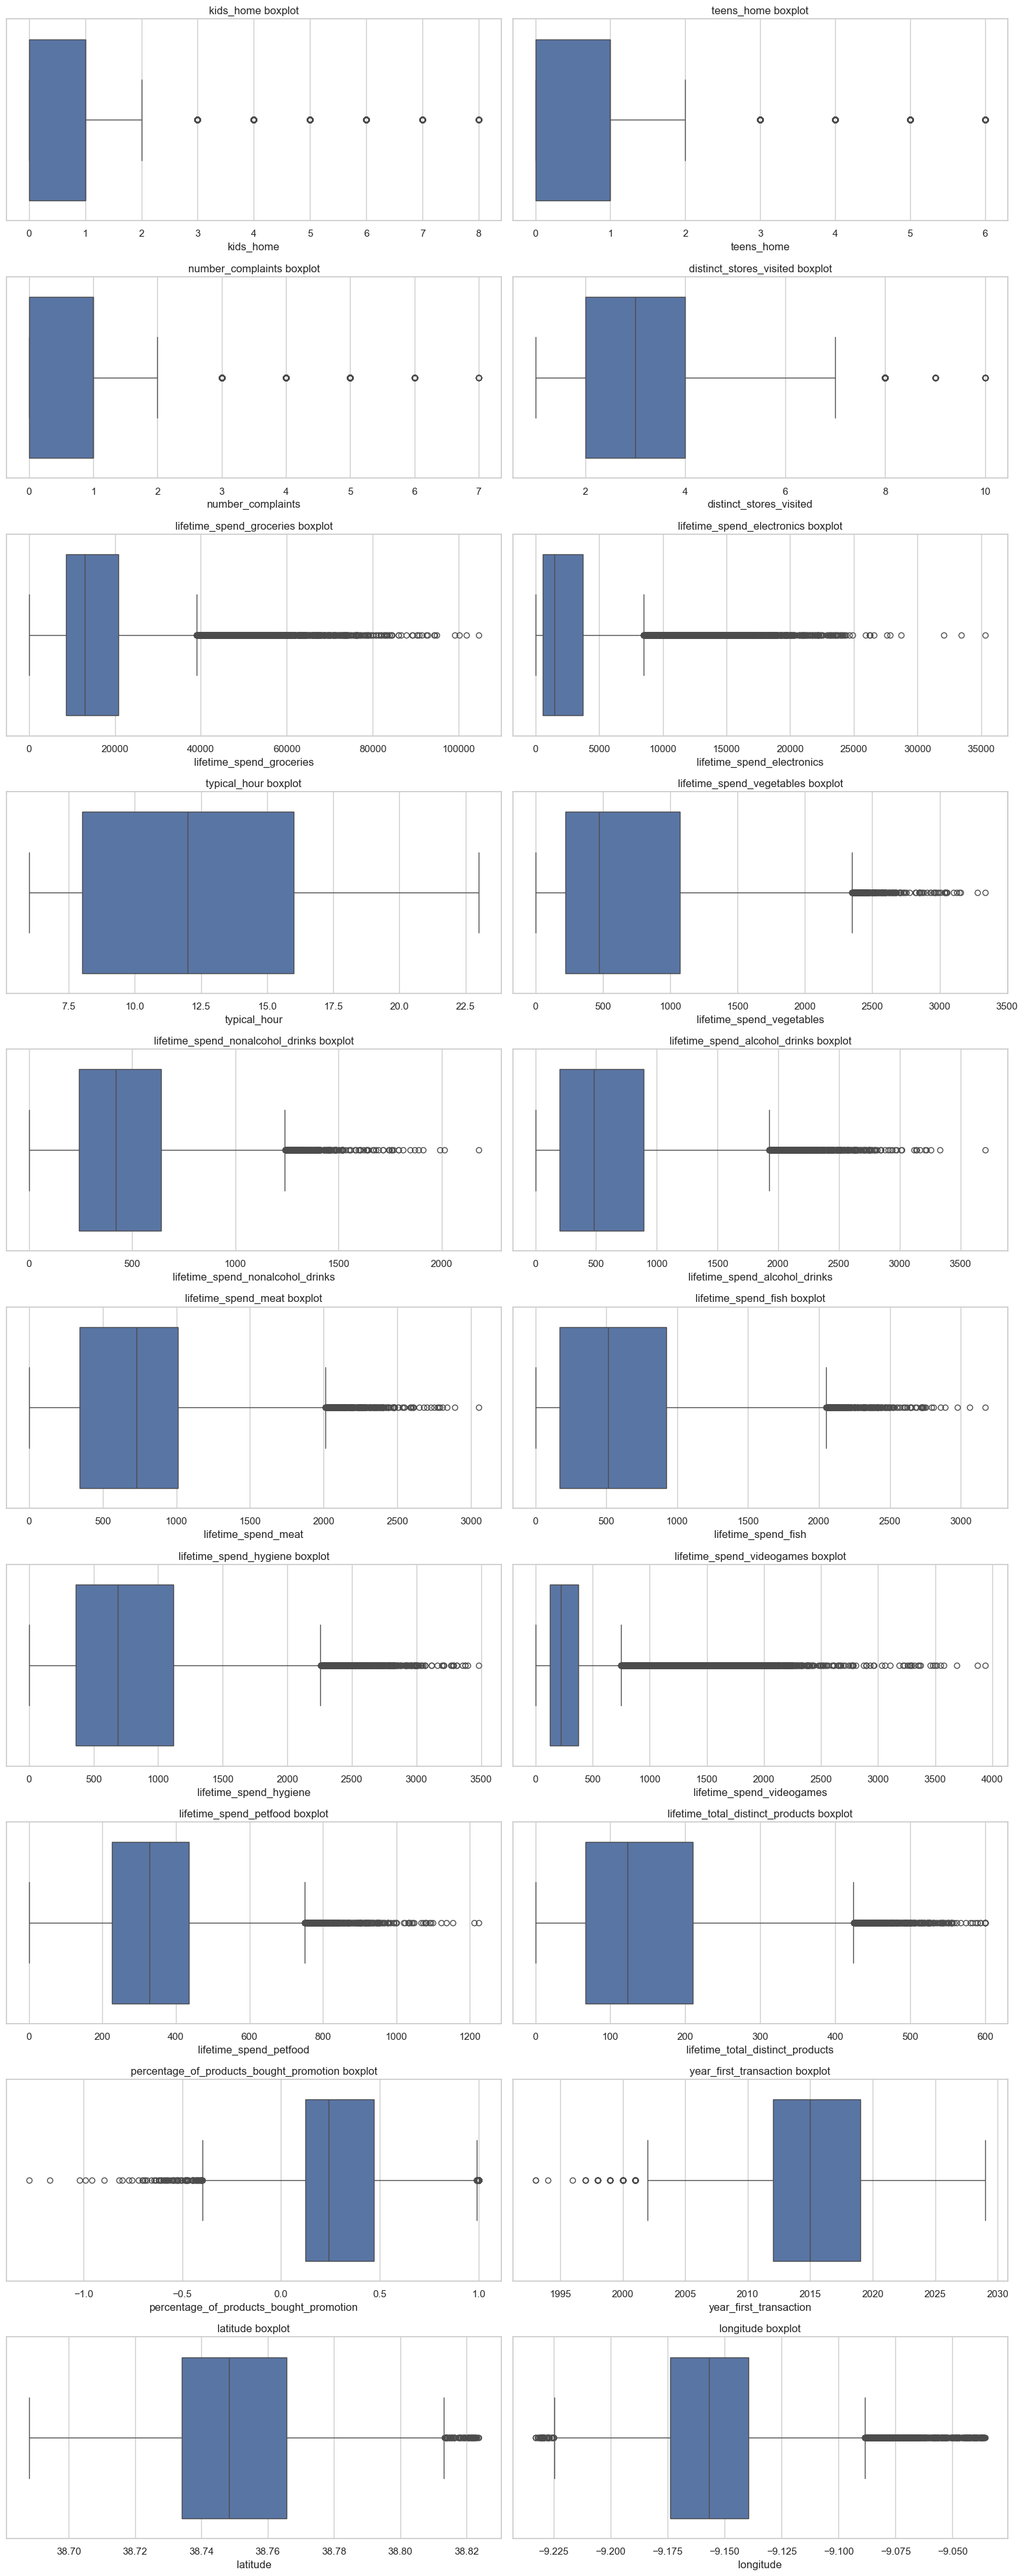

In [135]:
utils.plot_numeric_boxplots(ci, vars_to_plot)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The distribution plots confirm that spending variables are highly skewed, with a small number of customers spending much more than the rest. This supports two later decisions: separating the most atypical customers before fitting the clustering model, and leaving scaling as a modelling choice in the clustering notebook.
</div>

<a id="section-2-data-cleaning"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2. Data Cleaning</b></h2>
</div>


In [136]:
ci_clean = ci.copy()
print("Initial shape:", ci_clean.shape)

Initial shape: (33038, 25)


<a id="section-2-1-invalid-future-years"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2.1 Detecting Invalid Future Years</b></h2>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

To convert static dates into dynamic behavioral features, we first establish the current temporal baseline.

* **Objective:** Capture the current year using `pd.Timestamp.now().year`.
* **Application:** This value serves as the reference point for calculating:
    * **Customer Age:** Derived from `customer_birthdate`.
    * **Customer Tenure:** Calculated as the difference between the current year and the `year_first_transaction`.
* **Impact:** Transforming years and dates into "Age" and "Years as Customer" provides the clustering algorithm with numerical distances that represent lifecycle stages, which is far more predictive than raw date strings.

</div>

In [137]:
current_year = pd.Timestamp.now().year
print("Current year:", current_year)

Current year: 2026


In [138]:
invalid_years = ci_clean[ci_clean["year_first_transaction"] > current_year]
print("Invalid future years found:")
display(invalid_years["year_first_transaction"].unique())


Invalid future years found:


array([2029., 2028., 2027.])

In [139]:
invalid_years_rows = utils.get_invalid_years(ci_clean)

if not invalid_years_rows.empty:
    print(f"Future years detected: {invalid_years_rows['year_first_transaction'].unique()}")
    display(invalid_years_rows.head())

Future years detected: [2029. 2028. 2027.]


,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
17,25,Phd. Tom Fisher,male,03/17/2001 10:08 AM,0.0,0.0,NaN,2.0,8829.0,345.0,8.0,NaN,121.0,1657.0,1028.0,758.0,91.0,475.0,44.0,61.0,0.653237,2029.0,1.0,38.707590,-9.161818
28,37,Phd. Alonzo Crossan,male,09/29/2000 07:54 PM,1.0,1.0,0.0,5.0,25539.0,1089.0,7.0,907.0,1681.0,896.0,1153.0,962.0,1205.0,344.0,329.0,330.0,-0.184820,2028.0,1.0,38.729700,-9.196585
66,82,Msc. Heather Howie,female,09/25/2001 01:21 AM,0.0,0.0,0.0,2.0,8073.0,1372.0,8.0,123.0,304.0,1326.0,367.0,259.0,237.0,441.0,171.0,49.0,0.609053,2029.0,1.0,38.756427,-9.162594
92,115,Toni Sultan,female,03/14/1999 10:40 PM,1.0,1.0,2.0,1.0,17941.0,16101.0,23.0,268.0,596.0,1422.0,700.0,839.0,197.0,1409.0,294.0,161.0,0.414479,2027.0,1.0,38.722565,-9.149736
115,141,Bsc. Evelyn Hoffman,female,01/13/2000 07:00 AM,0.0,0.0,0.0,2.0,11257.0,412.0,9.0,1636.0,485.0,103.0,99.0,85.0,1846.0,115.0,14.0,191.0,0.304802,2028.0,1.0,38.754510,-9.183423


In [140]:
ci_clean, future_year_count = utils.set_future_years_to_missing(ci_clean, current_year)

print(f"Future transaction years set to NaN: {future_year_count}")
print(f"Records kept: {len(ci_clean)}")


Future transaction years set to NaN: 991
Records kept: 33038


<a id="section-2-2-negative-values"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2.2 Detecting Negative Values</b></h2>
</div>


In [141]:
negative_values = ci_clean.select_dtypes(include=['number']).lt(0).any()
negative_values

customer_id                                False
kids_home                                  False
teens_home                                 False
number_complaints                          False
distinct_stores_visited                    False
lifetime_spend_groceries                   False
lifetime_spend_electronics                 False
typical_hour                               False
lifetime_spend_vegetables                  False
lifetime_spend_nonalcohol_drinks           False
lifetime_spend_alcohol_drinks              False
lifetime_spend_meat                        False
lifetime_spend_fish                        False
lifetime_spend_hygiene                     False
lifetime_spend_videogames                  False
lifetime_spend_petfood                     False
lifetime_total_distinct_products           False
percentage_of_products_bought_promotion     True
year_first_transaction                     False
loyalty_card_number                        False
latitude            

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

### Negative Value Analysis

To ensure the logical consistency of our features before modeling, we scan all numerical columns for values below zero.

* **Objective:** Use `.lt(0).any()` to detect logical anomalies across numerical datatypes.
* **Findings:**
    * **`longitude`:** Contains negative values, which is **logically valid** because Lisbon is located west of the Greenwich meridian.
    * **`percentage_of_products_bought_promotion`:** Contains negative values, which is a **logical error** for a percentage metric.
* **Impact:** Identifying these anomalies prevents the inclusion of "placeholder" values (like -1 for missing data) that would otherwise distort the mean and variance of features during the clustering process.

</div>

<a id="section-2-3-negative-percentages"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2.3 Fixing Negative Percentages</b></h2>
</div>


In [142]:
ci_clean, invalid_promo_count = utils.set_invalid_promotion_to_missing(ci_clean)

print(f"Invalid promotion percentage values: {invalid_promo_count}")
display(ci_clean["percentage_of_products_bought_promotion"].describe())


Invalid promotion percentage values: 1755


count    30953.000000
mean         0.343870
std          0.268770
min          0.000005
25%          0.139284
50%          0.254525
75%          0.491430
max          1.000000
Name: percentage_of_products_bought_promotion, dtype: float64

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">


</div>

<a id="section-2-4-data-types"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2.4 Fixing Data Types</b></h2>
</div>


In [143]:
ci_clean = utils.parse_birthdate(ci_clean)

print("Invalid birthdates after parsing:", ci_clean["customer_birthdate"].isna().sum())


Invalid birthdates after parsing: 165


In [144]:
int_columns = [
    "kids_home",
    "teens_home",
    "number_complaints",
    "distinct_stores_visited",
    "typical_hour",
    "lifetime_total_distinct_products",
    "year_first_transaction",
]

ci_clean = utils.coerce_numeric_columns(ci_clean, int_columns)


In [145]:
display(ci_clean[['loyalty_card_number']].head())


,loyalty_card_number
0,1.0
1,1.0
2,NaN
3,1.0
4,1.0


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

To ensure mathematical operations and time series analyses function correctly, we cast raw object columns into their appropriate structural formats.

* **Objective:** Convert based on strings dates and mixed type numerical strings into usable `datetime64` and `numeric` formats.
* **Key Transformations:**
    * **Temporal Casting:** `customer_birthdate` is parsed using a specific format string (`%m/%d/%Y %I:%M %p`) to enable age calculations.
    * **Integer Enforcement:** Columns like `kids_home` and `number_complaints` are coerced to numeric types. By using `errors='coerce'`, any not numeric noise is safely converted to `NaN`.
* **Impact:** Standardizing types is critical for the "Temporal Baseline" established earlier. For instance, `loyalty_card_number` is revealed as a Boolean style float (1.0 or NaN), which can now be treated as a categorical flag for loyalty membership.

</div>

In [146]:
ci_clean = utils.apply_cyclic_transformation(ci_clean, "typical_hour", max_val=24)

print(ci_clean[["typical_hour", "typical_hour_sin", "typical_hour_cos"]].head())


   typical_hour  typical_hour_sin  typical_hour_cos
0           NaN               NaN               NaN
1           NaN               NaN               NaN
2          11.0          0.258819     -9.659258e-01
3          18.0         -1.000000     -1.836970e-16
4          17.0         -0.965926     -2.588190e-01


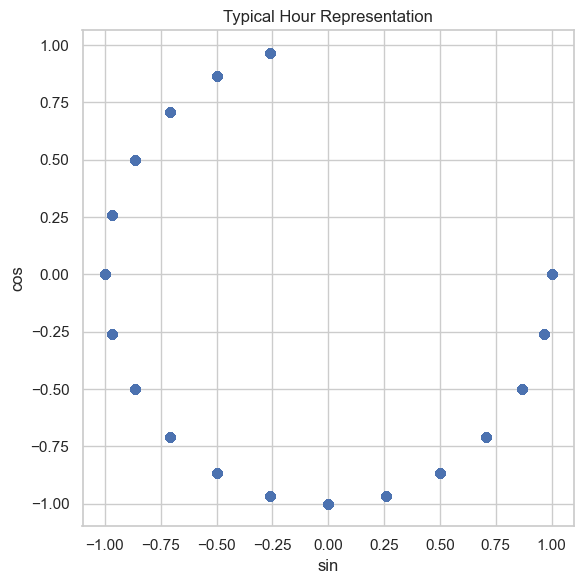

In [147]:
utils.plot_cyclic_hour(ci_clean)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">


Time of day data is inherently cyclical (23:00 is closer to 01:00 than it is to 13:00). To ensure our model understands this relationship, we map the linear `typical_hour` onto a 2D coordinate system.

* **Objective:** Transform the 24-hour cycle into Sine and Cosine components using a `cyclic_transformation`.
* **The Logic:** Raw numerical hours (0-23) create a "jump" or distance gap between the end of one day and the start of the next.
    * By mapping hours to a circle, **Hour 23** and **Hour 0** become spatially adjacent, preserving the temporal continuity of human behavior.
* **Impact:** The resulting scatter plot forms a perfect circle, confirming that the "Typical Hour" has been successfully projected into a format that allows clustering algorithms to calculate meaningful distances between different times of day.

</div>

In [148]:
print("Updated data types:")
display(ci_clean.dtypes)

Updated data types:


customer_id                                         int64
customer_name                                      object
customer_gender                                    object
customer_birthdate                         datetime64[ns]
kids_home                                         float64
teens_home                                        float64
number_complaints                                 float64
distinct_stores_visited                           float64
lifetime_spend_groceries                          float64
lifetime_spend_electronics                        float64
typical_hour                                      float64
lifetime_spend_vegetables                         float64
lifetime_spend_nonalcohol_drinks                  float64
lifetime_spend_alcohol_drinks                     float64
lifetime_spend_meat                               float64
lifetime_spend_fish                               float64
lifetime_spend_hygiene                            float64
lifetime_spend

In [149]:
binary_features = [
    col for col in ci_clean.columns
    if ci_clean[col].nunique() == 2
]

print("Binary features:")
display(binary_features)


Binary features:


['customer_gender']

<a id="section-2-5-missing-values-treatment"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2.5 Missing Values Treatment</b></h2>
</div>


In [150]:
print("Missing values BEFORE imputation:")
display(ci_clean.isna().sum())

Missing values BEFORE imputation:


customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_produc

In [151]:
ci_clean = utils.fill_zero_count_columns(
    ci_clean,
    columns=["kids_home", "teens_home", "number_complaints"],
)


In [152]:
ci_clean = utils.encode_loyalty_flag(ci_clean)

print(ci_clean["customer_loyalty_flag"].value_counts())


customer_loyalty_flag
1    19932
0    13106
Name: count, dtype: int64


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">


Handling null values is a critical step to prevent model bias and calculation errors. In this section, we address the sparsity discovered in several key features.

* **Objective:** Quantify missing data using `.isna().sum()` and apply specific to the domain imputation rules.
* **Treatment Logic:**
    * **Zero Imputation:** For count variables such as `kids_home`, `teens_home`, and `number_complaints`, missing values are treated as **0**, assuming the absence of a record implies a zero count.
    * **Flag Transformation:** The `loyalty_card_number` column is renamed to `customer_loyalty_flag` and converted into a binary indicator ($1$ for members, $0$ for customers without membership).
* **Impact:** By resolving the 13,106 missing loyalty entries and filling behavioral counts, we ensure the dataset is structurally complete. This prepares the "sparse" features for statistical analysis without losing significant row volume.

</div>

In [153]:
print(f"Shape before removing semi-constants: {ci_clean.shape}")

protected_cols = [
    'customer_id',
    'loyalty_card_number',
    'customer_loyalty_flag',
    'is_male',
    'education_level'
]

ci_clean = utils.remove_semi_constant_features(
    ci_clean,
    threshold=0.99,
    exclude_cols=protected_cols
)

print(f"Shape after removing semi-constants: {ci_clean.shape}")


Shape before removing semi-constants: (33038, 27)
Semi-constant columns removed (>=99% identical): []
Shape after removing semi-constants: (33038, 27)


<a id="section-3-aggregation-feature-engineering"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>3. Aggregation Feature Engineering</b></h2>
</div>


In [154]:
ci_clean, age_summary = utils.add_customer_age(ci_clean)

print(f"Minimum Age: {age_summary['min_age']}")
print(f"Maximum Age: {age_summary['max_age']}")
print(f"Invalid or suspicious ages: {age_summary['invalid_count']}")


Minimum Age: 24.0
Maximum Age: 86.0
Invalid or suspicious ages: 0


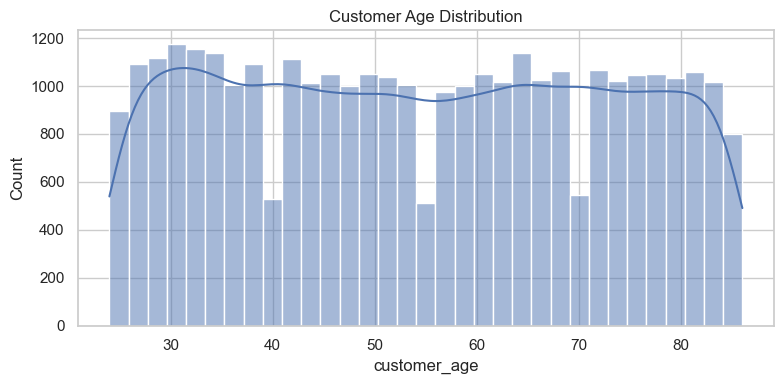

In [155]:
utils.plot_age_distribution(ci_clean)


In [156]:
education_df = ci_clean.apply(utils.get_education_info, axis=1)

ci_clean["education_level"] = education_df[0].astype(int)
ci_clean["clean_customer_name"] = education_df[1]

print("Distribution of identified education levels:")
print(ci_clean["education_level"].value_counts().sort_index())

display(ci_clean[["customer_name", "clean_customer_name", "education_level"]].head())


Distribution of identified education levels:
education_level
12    17731
15     5154
17     5057
22     5096
Name: count, dtype: int64


,customer_name,clean_customer_name,education_level
0,Bsc. Crystal Kitchens,Crystal Kitchens,15
1,Bsc. Glenda Bauman,Glenda Bauman,15
2,Msc. Antonio Campbell,Antonio Campbell,17
3,John Kelling,John Kelling,12
4,Arthur Dematteo,Arthur Dematteo,12


In [157]:
ci_clean = utils.encode_gender(ci_clean)
display(ci_clean[["customer_gender", "is_male"]].head())


,customer_gender,is_male
0,female,0
1,female,0
2,male,1
3,male,1
4,male,1


In [158]:
ci_clean.drop(columns=['customer_gender'], inplace=True)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:20px; border-radius:10px;">

This step turns raw demographic information into variables that can be used in modelling.

* <b>Education level:</b> extracted safely from <code>customer_name</code> using regex, so customer names are not accidentally corrupted.
* <b>Gender:</b> encoded as a binary flag, making it compatible with based on distance models.
* <b>Customer age:</b> calculated from birthdate and checked for unrealistic values before imputation.

The result is a cleaner dataset with less text noise and more useful numerical signal.
* <b>Note on the education scale:</b> the year values (12 / 15 / 17 / 22) are an assumption about typical degree duration, and customers with no academic prefix are coded as 12 — i.e. “unknown” is grouped with high school. This is a documented assumption, not a measured fact.

</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
After creating the main demographic and loyalty features, we briefly inspect their distributions. These variables are useful for profiling and interpretation, even when some of them are not used directly in the clustering distance.
</div>

,column,value,count,percentage_%
0,is_male,0.0,16577,50.18
1,is_male,1.0,16461,49.82
2,customer_loyalty_flag,1.0,19932,60.33
3,customer_loyalty_flag,0.0,13106,39.67
4,education_level,12.0,17731,53.67
5,education_level,15.0,5154,15.60
6,education_level,22.0,5096,15.42
7,education_level,17.0,5057,15.31
8,kids_home,1.0,16012,48.47
9,kids_home,0.0,9533,28.85


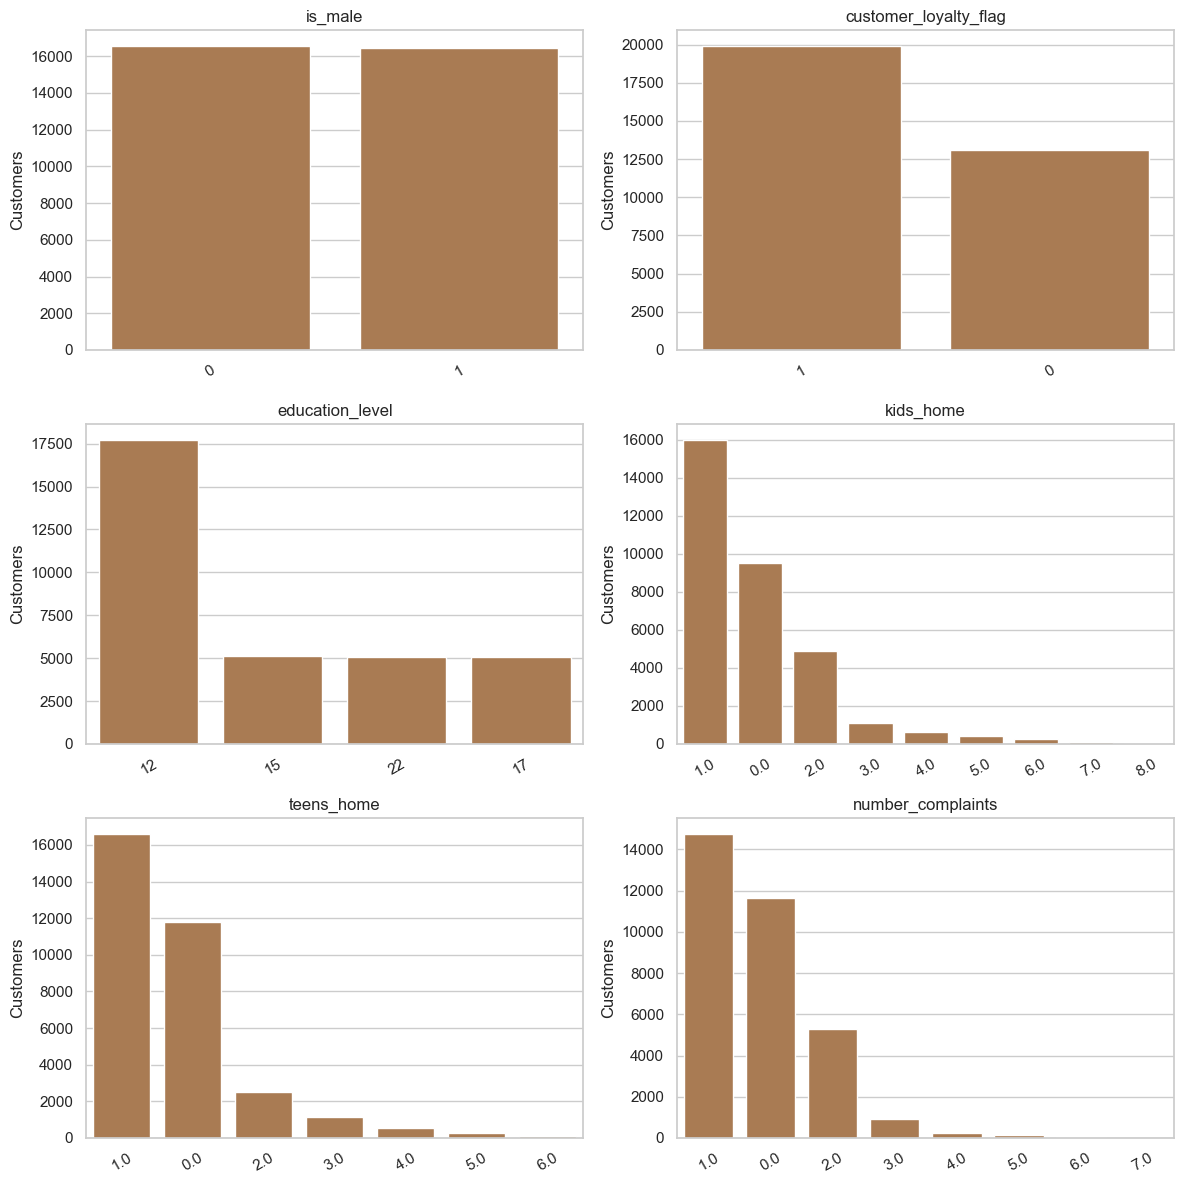

In [159]:
categorical_review_cols = [
    "is_male",
    "customer_loyalty_flag",
    "education_level",
    "kids_home",
    "teens_home",
    "number_complaints",
]

categorical_review = utils.categorical_summary(ci_clean, categorical_review_cols)
display(categorical_review)

utils.plot_categorical_summary(ci_clean, categorical_review_cols)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The categorical and count distributions help verify that the engineered features are reasonable before export. Gender is kept as a binary flag, loyalty is represented separately from the raw card number, and education is treated as an approximate numeric proxy derived from name prefixes.
</div>

In [160]:
ci_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,33038.0,19974.265785,11538.538632,3.000000,9985.250000,1.995150e+04,29964.750000,40000.000000
kids_home,33038.0,1.104970,1.149796,0.000000,0.000000,1.000000e+00,1.000000,8.000000
teens_home,33038.0,0.889915,0.962263,0.000000,0.000000,1.000000e+00,1.000000,6.000000
number_complaints,33038.0,0.912222,0.895203,0.000000,0.000000,1.000000e+00,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000e+00,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,1.300250e+04,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1.470000e+03,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,1.200000e+01,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,4.710000e+02,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,4.210000e+02,640.000000,2180.000000


In [161]:
ci_clean.columns

Index(['customer_id', 'customer_name', 'kids_home', 'teens_home',
       'number_complaints', 'distinct_stores_visited',
       'lifetime_spend_groceries', 'lifetime_spend_electronics',
       'typical_hour', 'lifetime_spend_vegetables',
       'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks',
       'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene',
       'lifetime_spend_videogames', 'lifetime_spend_petfood',
       'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'year_first_transaction',
       'customer_loyalty_flag', 'latitude', 'longitude', 'typical_hour_sin',
       'typical_hour_cos', 'customer_age', 'education_level',
       'clean_customer_name', 'is_male'],
      dtype='object')

<a id="section-4-outlier-separation-and-imputation"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>4. Consensus Outlier Separation and KNN Imputation</b></h2>
</div>


In [162]:
ci_clean.drop(columns=["customer_name", "clean_customer_name"], inplace=True, errors="ignore")


<div style="background-color:#7E6A43; color:#F3EEE6; padding:20px; border-radius:10px;">

Before imputing missing values, the most atypical customers are separated into an outlier dataset. The rule is conservative: a customer is only kept aside when it is simultaneously flagged by three methods.

* <b>IQR:</b> detects unusually high or low values in numerical variables.
* <b>DBSCAN:</b> identifies observations located in sparse areas of the feature space.
* <b>SOM:</b> highlights customers with high reconstruction error in a SOM map.

The thresholds are kept below the 5% reference limit. These customers are not discarded; they are exported separately and later assigned to the closest final segment in the clustering notebook.

</div>


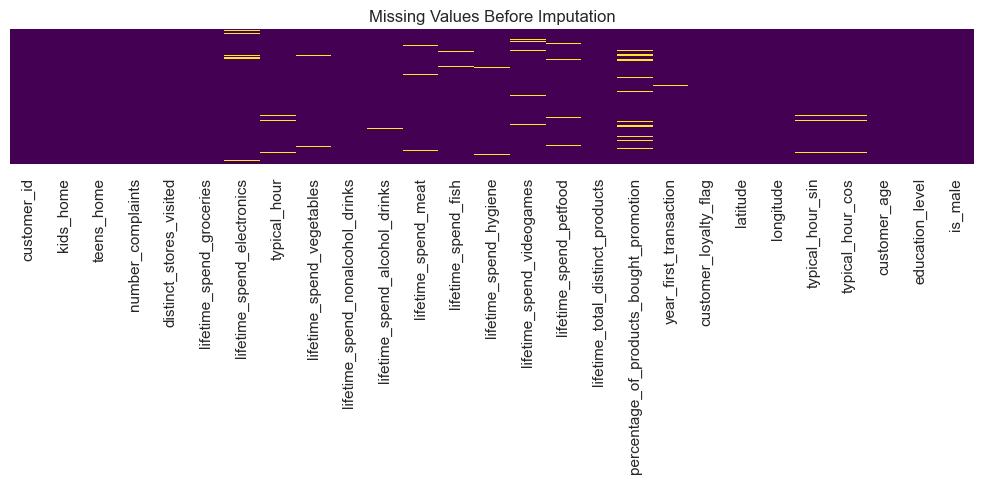

                                         Missing Count  Percentage (%)
percentage_of_products_bought_promotion           2085            6.31
lifetime_spend_fish                                991            3.00
year_first_transaction                             991            3.00
lifetime_spend_electronics                         661            2.00
typical_hour                                       661            2.00
lifetime_spend_vegetables                          661            2.00
lifetime_spend_meat                                661            2.00
lifetime_spend_videogames                          661            2.00
lifetime_spend_petfood                             661            2.00
typical_hour_sin                                   661            2.00
typical_hour_cos                                   661            2.00
distinct_stores_visited                            330            1.00
lifetime_spend_alcohol_drinks                      330            1.00
lifeti

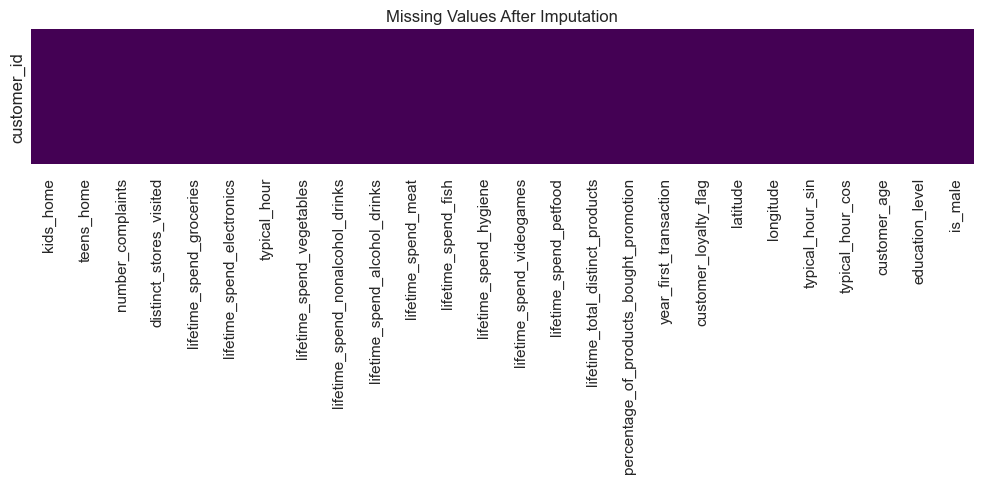

In [163]:
ci_clean, outlier_dataset, outlier_summary = utils.separate_outliers_and_impute_regular(
    ci_clean,
    index_col="customer_id",
    outlier_method="consensus",
    iqr_k=2.0,
    dbscan_eps=1.0,
    som_percentile=95,
    max_remove_pct=5.0,
)


In [164]:
to_int = [
    "kids_home",
    "teens_home",
    "number_complaints",
    "distinct_stores_visited",
    "lifetime_total_distinct_products",
    "year_first_transaction",
    "customer_loyalty_flag",
    "education_level",
    "is_male",
]

ci_clean = utils.cast_nullable_int(ci_clean, to_int)


In [165]:
ci_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32056 entries, 3 to 40000
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   kids_home                                32056 non-null  Int64  
 1   teens_home                               32056 non-null  Int64  
 2   number_complaints                        32056 non-null  Int64  
 3   distinct_stores_visited                  32056 non-null  Int64  
 4   lifetime_spend_groceries                 32056 non-null  float64
 5   lifetime_spend_electronics               32056 non-null  float64
 6   typical_hour                             32056 non-null  float64
 7   lifetime_spend_vegetables                32056 non-null  float64
 8   lifetime_spend_nonalcohol_drinks         32056 non-null  float64
 9   lifetime_spend_alcohol_drinks            32056 non-null  float64
 10  lifetime_spend_meat                      32056 non-

<a id="section-5-transformation-feature-engineering"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>5. Transformation Feature Engineering</b></h2>
</div>


In [166]:
ci_clean = utils.engineer_clustering_features(
    ci_clean,
    current_year,
    keep_absolute_spend=True
)

print("Columns after feature engineering:")
display(ci_clean.columns.tolist())

absolute_spend_cols = [c for c in ci_clean.columns if c.startswith("lifetime_spend_")]

print(f"Absolute lifetime spend columns kept: {len(absolute_spend_cols)}")
for c in absolute_spend_cols:
    print("-", c)


Columns after feature engineering:


['kids_home',
 'teens_home',
 'number_complaints',
 'distinct_stores_visited',
 'lifetime_spend_groceries',
 'lifetime_spend_vegetables',
 'lifetime_spend_nonalcohol_drinks',
 'lifetime_spend_alcohol_drinks',
 'lifetime_spend_meat',
 'lifetime_spend_fish',
 'lifetime_spend_hygiene',
 'lifetime_spend_petfood',
 'lifetime_total_distinct_products',
 'percentage_of_products_bought_promotion',
 'customer_loyalty_flag',
 'latitude',
 'longitude',
 'typical_hour_sin',
 'typical_hour_cos',
 'customer_age',
 'education_level',
 'is_male',
 'tenure',
 'total_children',
 'lifetime_spend_technology',
 'log_total_spend']

Absolute lifetime spend columns kept: 9
- lifetime_spend_groceries
- lifetime_spend_vegetables
- lifetime_spend_nonalcohol_drinks
- lifetime_spend_alcohol_drinks
- lifetime_spend_meat
- lifetime_spend_fish
- lifetime_spend_hygiene
- lifetime_spend_petfood
- lifetime_spend_technology


Feature engineering is applied after data cleaning and imputation. The exported dataset keeps absolute lifetime spend variables because the final scaling decision is made in the clustering notebook.


<div style="background-color:#7E6A43; color:#F3EEE6; padding:20px; border-radius:10px;">

## Absolute spend feature set

This feature set keeps absolute lifetime spending variables as the main spending block, together with engineered demographic and behavioural features such as age, cyclic hour, education years, tenure, loyalty flag and gender.

A separate absolute spend view is created to inspect the final feature structure before export.

</div>


In [167]:
ci_absolute_spend = utils.make_absolute_spend_view(ci_clean)

print("Absolute-spend style dataset shape:", ci_absolute_spend.shape)
print("Absolute-spend style columns:")
for col in ci_absolute_spend.columns:
    print("-", col)


Absolute-spend style dataset shape: (32056, 24)
Absolute-spend style columns:
- kids_home
- teens_home
- number_complaints
- distinct_stores_visited
- lifetime_spend_groceries
- lifetime_spend_vegetables
- lifetime_spend_nonalcohol_drinks
- lifetime_spend_alcohol_drinks
- lifetime_spend_meat
- lifetime_spend_fish
- lifetime_spend_hygiene
- lifetime_spend_petfood
- lifetime_spend_technology
- lifetime_total_distinct_products
- percentage_of_products_bought_promotion
- latitude
- longitude
- age
- hour_sin
- hour_cos
- years_education
- years_since_first_transaction
- has_loyalty_card
- customer_gender


In [168]:
ci_clean.columns

Index(['kids_home', 'teens_home', 'number_complaints',
       'distinct_stores_visited', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'customer_loyalty_flag',
       'latitude', 'longitude', 'typical_hour_sin', 'typical_hour_cos',
       'customer_age', 'education_level', 'is_male', 'tenure',
       'total_children', 'lifetime_spend_technology', 'log_total_spend'],
      dtype='object')

<div style="background-color:#7E6A43; color:#F3EEE6; padding:20px; border-radius:10px;">

Here we create broader customer features from the raw transaction and demographic information.

This version keeps the **absolute lifetime spending variables** as the main spending block. This is useful because a scaled clustering model can capture both customer value and purchasing intensity across categories.

The final clustering dataset uses absolute lifetime spending variables, so customer value and spending intensity are preserved across categories.

The actual scaler and final feature set are chosen in the clustering notebook.

</div>


<a id="section-6-outlier-diagnostics"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>6. Outlier Diagnostics</b></h2>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:20px; border-radius:10px;">

The plots below are used as a final visual check of the main skewed variables after preprocessing. At this point, the extreme subset has already been separated, so these diagnostics help confirm whether the regular customer base is more stable before the clustering stage.

</div>


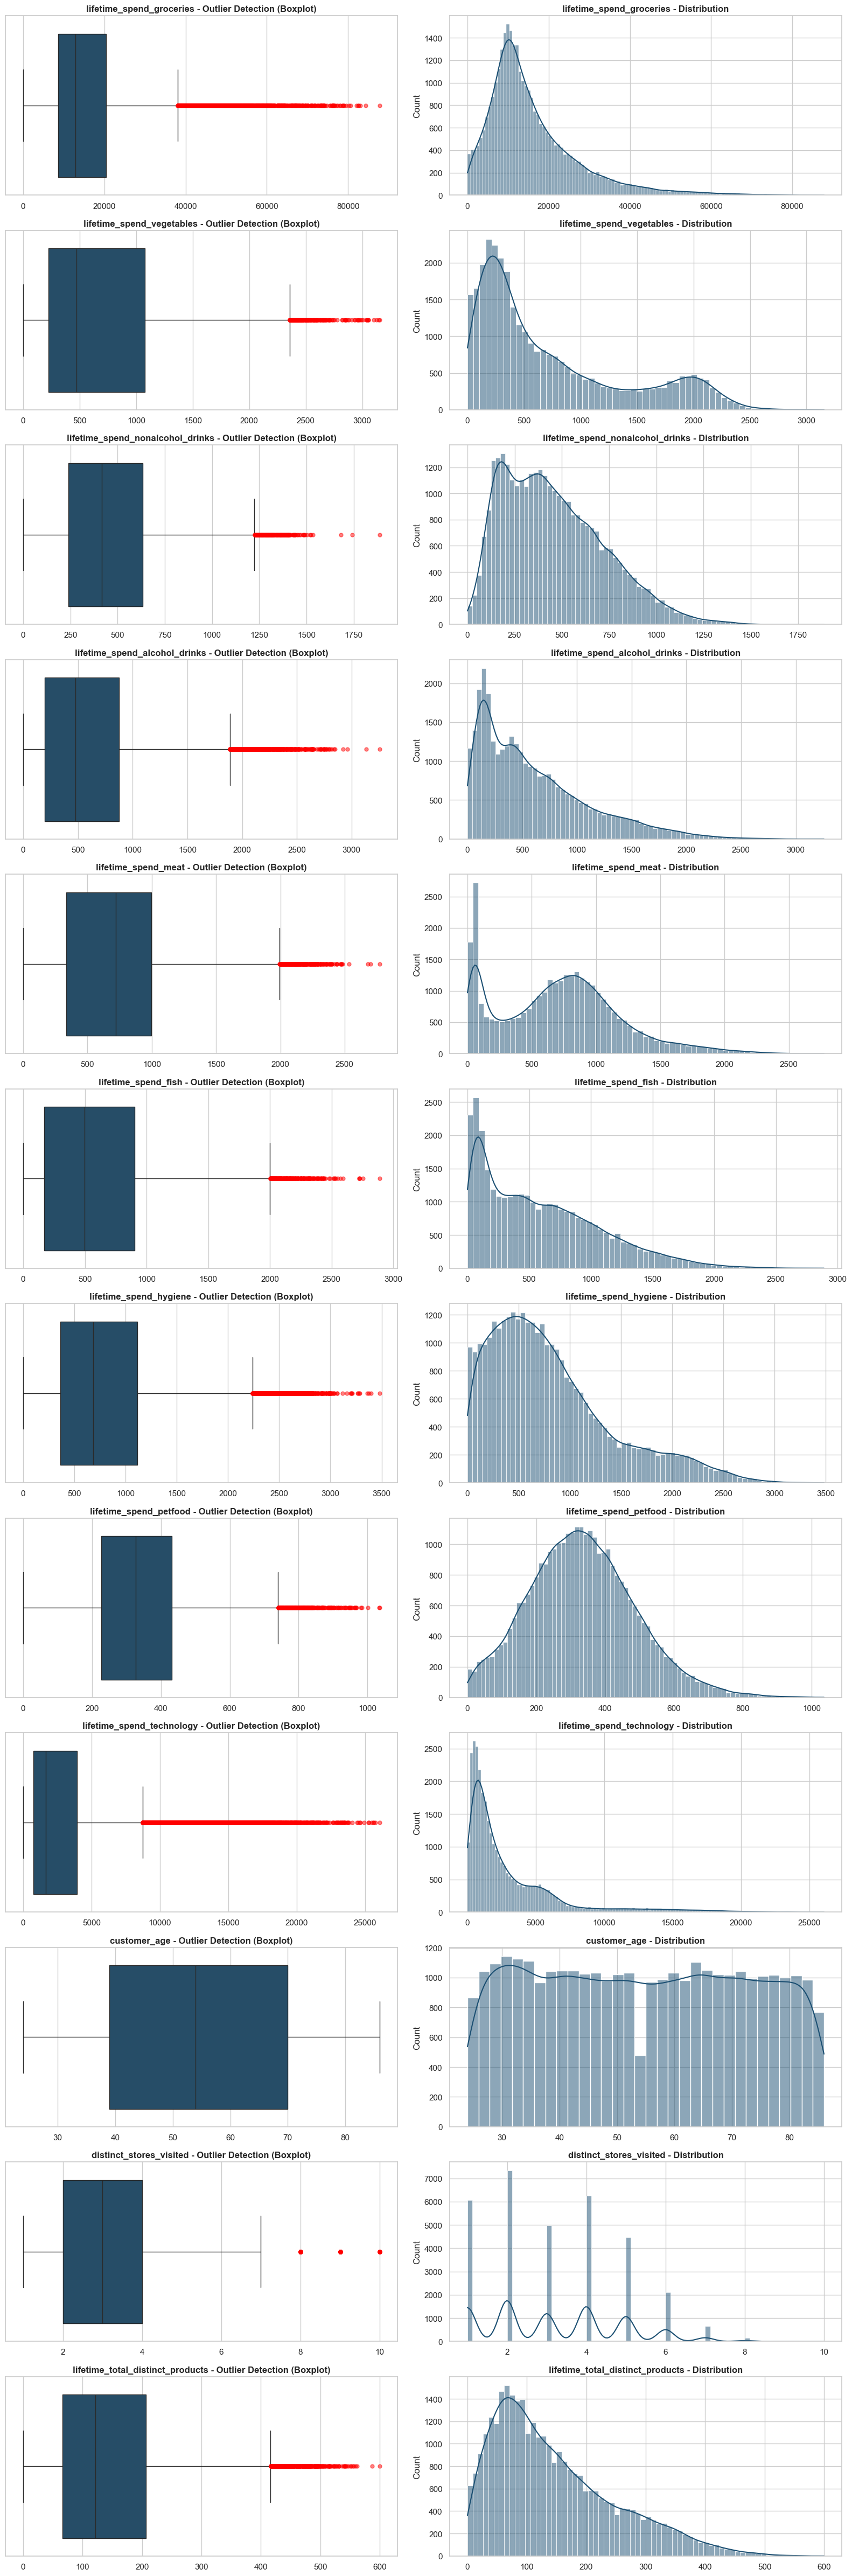

In [169]:
spend_cols = [col for col in ci_clean.columns if col.startswith("lifetime_spend_")]
other_numeric = [
    "customer_age",
    "distinct_stores_visited",
    "lifetime_total_distinct_products",
]
cols_to_visualize = [col for col in spend_cols + other_numeric if col in ci_clean.columns]

utils.plot_outlier_diagnostics(ci_clean, cols_to_visualize)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
Some high values remain visible in the boxplots after preprocessing. This is expected because lifetime spending variables are naturally skewed. The goal was not to remove every univariate extreme value, but to keep valid high spending customers while separating only the most atypical multivariate cases.
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
After the conservative outlier separation, the regular customer base still contains natural variation, but the most extreme observations are kept aside. This reduces the risk that a small number of atypical customers dominate the clustering distances.
</div>

<a id="section-7-multivariate-analysis"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>7. Multivariate Analysis: Feature Correlation</b></h2>
</div>


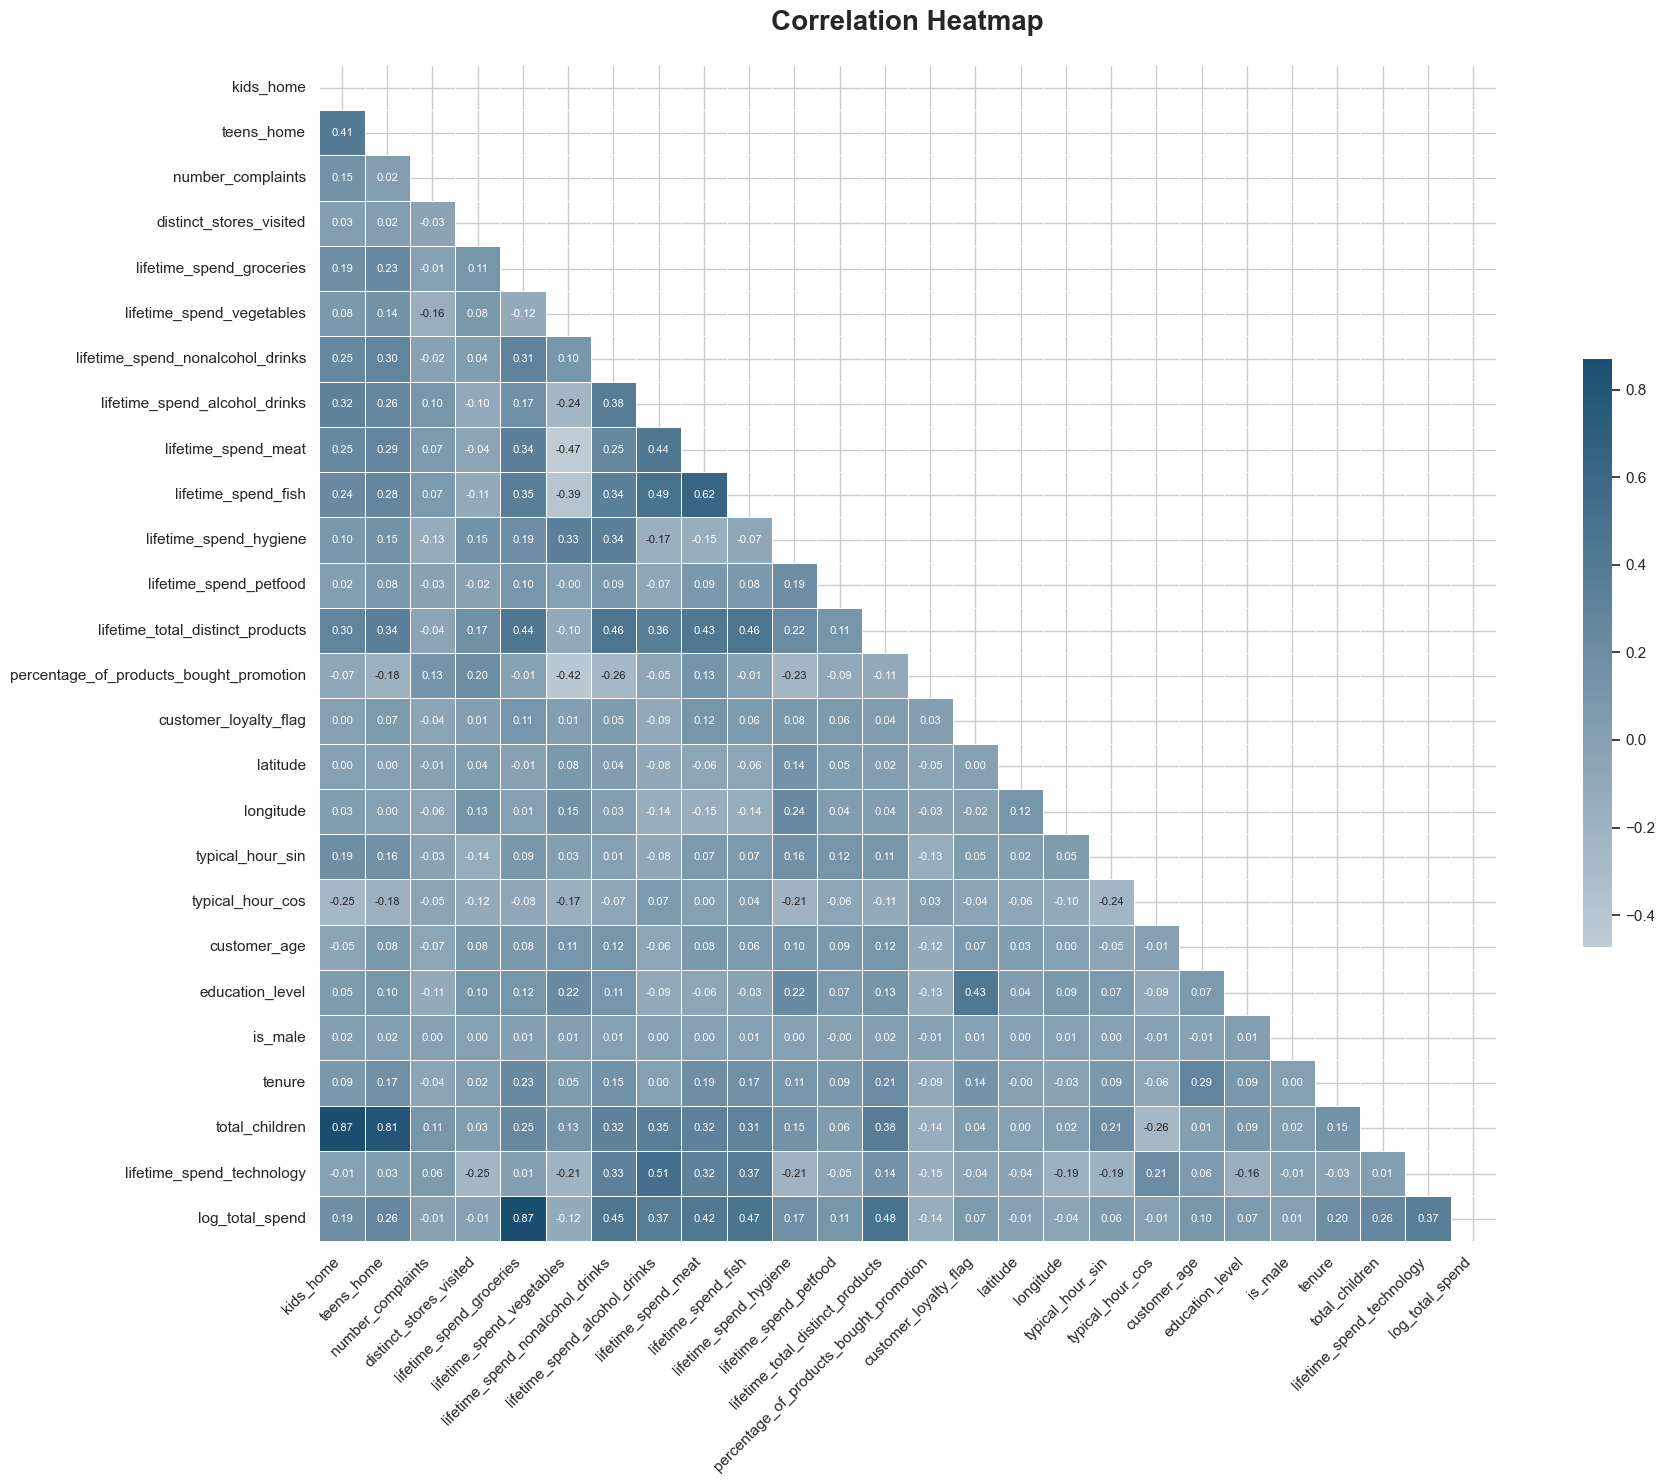

In [170]:
cols_to_corr = utils.correlation_columns(
    ci_clean,
    exclude_cols=["loyalty_card_number"],
)

utils.cor_heatmap(ci_clean[cols_to_corr].corr())


In [171]:
high_corrs = utils.get_high_correlations(ci_clean, threshold=0.7)

display(high_corrs)

,Variable 1,Variable 2,Correlation
0,total_children,kids_home,0.869776
2,log_total_spend,lifetime_spend_groceries,0.865030
1,total_children,teens_home,0.806247


<div style="background-color:#7E6A43; color:#F3EEE6; padding:20px; border-radius:10px;">

At this stage, we check how strongly numerical variables are related to one another. Highly redundant features can distort based on distance clustering by giving the same information more than one weight.

In the final exported dataset, `year_first_transaction` is replaced by `tenure`, and `typical_hour` is replaced by its cyclic sine/cosine representation. The household variables are reviewed later in the clustering notebook, where only one family representation is used in the distance calculation.

</div>


In [172]:
ci_clean

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,customer_loyalty_flag,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,education_level,is_male,tenure,total_children,lifetime_spend_technology,log_total_spend
customer_id,,,,,,,,,,,,,,,,,,,,,,,,,,
3,1,1,1,3,11731.0,373.0,323.0,177.0,28.0,213.0,552.0,384.0,189,0.631599,1,38.794428,-9.215739,0.010342,-2.649291e-01,56.0,15,0,6,2,4809.0,9.830433
4,1,0,0,2,13694.0,2012.0,533.0,95.0,43.0,15.0,1880.0,665.0,130,0.149890,1,38.751711,-9.179611,0.193185,-8.810167e-01,50.0,15,0,13,1,1296.0,9.915120
5,0,0,0,2,12407.0,555.0,101.0,118.0,1265.0,273.0,507.0,222.0,81,0.069126,0,38.780678,-9.160656,0.258819,-9.659258e-01,54.0,17,1,21,0,101.0,9.651816
7,0,0,2,1,7493.0,84.0,757.0,1133.0,972.0,1083.0,485.0,184.0,92,0.253609,1,38.739548,-9.148679,-1.000000,-1.665335e-16,43.0,12,1,5,0,2761.0,9.612667
8,0,0,3,1,9187.0,380.0,592.0,718.0,1068.0,1015.0,297.0,441.0,6,0.186569,1,38.733071,-9.188188,-0.965926,-2.588190e-01,56.0,12,1,5,0,12099.0,10.158052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39996,0,0,2,1,475.0,190.0,573.0,994.0,1020.0,1154.0,62.0,366.0,162,0.261352,0,38.742306,-9.163971,-0.119980,-5.249689e-01,53.0,12,1,12,0,15086.0,9.899530
39997,1,0,1,1,8430.0,291.0,497.0,1417.0,1323.0,602.0,220.0,227.0,97,0.143479,0,38.748505,-9.193445,-0.707107,7.071068e-01,71.0,12,1,12,1,16513.0,10.292857
39998,1,1,0,4,8029.0,1600.0,494.0,117.0,307.0,65.2,1719.0,258.0,206,0.181917,0,38.776003,-9.137943,-0.500000,-8.660254e-01,81.0,12,0,14,2,1569.0,9.558120


<a id="section-8-feature-selection-and-export"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>8. Feature Selection and Final Export</b></h2>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:20px; border-radius:10px;">

## Final clustering dataset

This step prepares the dataset that will be used in the clustering notebook.

The exported dataset is intentionally **unscaled**. It includes absolute lifetime spend features and engineered behavioural variables. Scaling is not applied here because the scaler is part of the clustering model design and must be fitted consistently inside the clustering notebook.

This allows us to compare alternatives such as MinMaxScaler, RobustScaler and StandardScaler before deciding the final KMeans pipeline.

</div>

In [173]:
final_feature_check = pd.DataFrame([
    {
        "raw_feature": "year_first_transaction",
        "replacement": "tenure",
        "status": "removed from final export",
        "reason": "tenure is the customer-lifecycle variable used downstream",
    },
    {
        "raw_feature": "typical_hour",
        "replacement": "typical_hour_sin + typical_hour_cos",
        "status": "removed from final export",
        "reason": "the cyclic representation preserves time-of-day distance",
    },
])

display(final_feature_check)

high_corrs = utils.get_high_correlations(ci_clean, threshold=0.8)
display(high_corrs)

absolute_spend_cols = [c for c in ci_clean.columns if c.startswith("lifetime_spend_")]
print("Absolute spend features kept for clustering:")
for col in absolute_spend_cols:
    print("-", col)

print()
print("Final columns exported:")
print(list(ci_clean.columns))


,raw_feature,replacement,status,reason
0,year_first_transaction,tenure,removed from final export,tenure is the customer-lifecycle variable used...
1,typical_hour,typical_hour_sin + typical_hour_cos,removed from final export,the cyclic representation preserves time-of-da...


,Variable 1,Variable 2,Correlation
0,total_children,kids_home,0.869776
2,log_total_spend,lifetime_spend_groceries,0.865030
1,total_children,teens_home,0.806247


Absolute spend features kept for clustering:
- lifetime_spend_groceries
- lifetime_spend_vegetables
- lifetime_spend_nonalcohol_drinks
- lifetime_spend_alcohol_drinks
- lifetime_spend_meat
- lifetime_spend_fish
- lifetime_spend_hygiene
- lifetime_spend_petfood
- lifetime_spend_technology

Final columns exported:
['kids_home', 'teens_home', 'number_complaints', 'distinct_stores_visited', 'lifetime_spend_groceries', 'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_petfood', 'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 'customer_loyalty_flag', 'latitude', 'longitude', 'typical_hour_sin', 'typical_hour_cos', 'customer_age', 'education_level', 'is_male', 'tenure', 'total_children', 'lifetime_spend_technology', 'log_total_spend']


The preprocessing notebook exports an unscaled dataset. Scaling is treated as a modelling choice in the clustering notebook, where different scalers can be compared on the same final feature set.


<div style="background-color:#7E6A43; color:#F3EEE6; padding:20px; border-radius:10px;">

## Export final files

The final cell only saves the prepared datasets. It does not recreate variables automatically, so the workflow stays clear and predictable when the notebook is run from top to bottom.

</div>

In [174]:
if "outlier_dataset" in locals():
    outlier_dataset = utils.align_outlier_features(
        outlier_dataset,
        reference_df=ci_clean,
        current_year=current_year,
    )


Outlier columns match regular columns: True
Outlier dataset shape: (982, 26)


The outlier dataset is aligned with the regular dataset before export, so both files contain the same engineered variables and can be used consistently in the clustering stage.


In [175]:
utils.export_preprocessing_outputs(
    regular_df=ci_clean,
    outlier_df=outlier_dataset if "outlier_dataset" in locals() else None,
    output_dir="../datasets",
)


Regular dataset exported UNSCALED: (32056, 26)
Outlier dataset exported UNSCALED: (982, 26)
Absolute lifetime spend columns exported: 9
['lifetime_spend_groceries', 'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_petfood', 'lifetime_spend_technology']
All exported columns:
['kids_home', 'teens_home', 'number_complaints', 'distinct_stores_visited', 'lifetime_spend_groceries', 'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_petfood', 'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 'customer_loyalty_flag', 'latitude', 'longitude', 'typical_hour_sin', 'typical_hour_cos', 'customer_age', 'education_level', 'is_male', 'tenure', 'total_children', 'lifetime_spend_technology', 'log_total_spend

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The final summary checks that preprocessing preserved the customer base, exported the expected files and produced a complete unscaled dataset for the clustering notebook.
</div>

In [176]:
exported_files = ["info_clustering_unscaled.csv"]
if "outlier_dataset" in locals():
    exported_files.append("outlier_dataset.csv")

preprocessing_summary = utils.preprocessing_summary_table(
    raw_df=ci,
    regular_df=ci_clean,
    outlier_df=outlier_dataset if "outlier_dataset" in locals() else None,
    exported_files=exported_files,
)

display(preprocessing_summary)

,item,value
0,Initial rows,33038
1,Regular rows exported,32056
2,Outlier rows kept aside,982
3,Total rows preserved,33038
4,Final exported features,26
5,Missing values in regular export,0
6,Absolute spend features,9
7,Exported files,"info_clustering_unscaled.csv, outlier_dataset.csv"


<div style="background-color:#7E6A43; color:#F3EEE6; padding:20px; border-radius:10px;">

The main unscaled clustering dataset is exported as <code>info_clustering_unscaled.csv</code>. If the extreme spender subset was created earlier, it is also exported as <code>outlier_dataset.csv</code>.

Both exports preserve the DataFrame index, which is important because <code>customer_id</code> was moved to the index to protect it from KNN imputation and scaling.

</div>
